In [18]:
import numpy as np
import glob
import cv2
import re
from tqdm import tqdm
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import matplotlib
import os
import pickle
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')


In [19]:
# Load your pickle file
exp_name = '20241109_3'
#pickle_path = '/Volumes/ReiterU/Anouk/basler_data/'+ exp_name+ '/'
#output_folder_path = '/Volumes/ReiterU/Anouk/basler_data/'+ exp_name+ '/'
#local_folder_path = "/Users/anoukberaud/Library/CloudStorage/OneDrive-OIST/Stephens_rotation/research_results/" + exp_name + '/'


pickle_path = '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/'+ exp_name+ '/'
output_folder_path = '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/'+ exp_name+ '/'
local_folder_path = '/home/user/Documents/Stephens_rotation/basler' + exp_name + '/'


pickle_name_aruco_1 = '_aruco_realigned_col1.pkl'
pickle_name_aruco_2 = '_aruco_realigned_col2.pkl'

col_1, col_2 = 9, 11

In [20]:
def read_pickle_file_with_load(pickle_path, pickle_name):
    """
    Read a DataFrame from a pickle file using `pickle.load`, ensuring the file exists.

    Parameters:
    - pickle_path (str): Path to the folder where the pickle file is located.
    - pickle_name (str): Name of the pickle file (including '.pkl').

    Returns:
    - pd.DataFrame: Loaded DataFrame.
    """
    # Full path to the pickle file
    pickle_full_path = os.path.join(pickle_path, pickle_name)
    
    try:
        print(f"Reading DataFrame from {pickle_full_path} using `pickle.load`...")
        with open(pickle_full_path, 'rb') as f:
            data = pickle.load(f)
        print(f"File '{pickle_name}' read successfully.")
        return data
    except FileNotFoundError:
        print(f"Error: File '{pickle_full_path}' not found.")
    except Exception as e:
        print(f"Error while reading file: {e}")


In [21]:
df_colony_1 = read_pickle_file_with_load(output_folder_path, exp_name + pickle_name_aruco_1)
df_colony_2 = read_pickle_file_with_load(output_folder_path, exp_name + pickle_name_aruco_2)


Reading DataFrame from /run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241109_3/20241109_3_aruco_realigned_col1.pkl using `pickle.load`...
File '20241109_3_aruco_realigned_col1.pkl' read successfully.
Reading DataFrame from /run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241109_3/20241109_3_aruco_realigned_col2.pkl using `pickle.load`...
File '20241109_3_aruco_realigned_col2.pkl' read successfully.


In [22]:
# Get active aruco IDs using arbitrary cutoff 
def get_aruco_ids(df):

    filtered_df = df[df['ARUCO_number'] < 301]

    
    # Group by 'Aruco_id' and count non-zero values in 'X'
    counts = filtered_df.groupby('ARUCO_number')['X'].apply(lambda x: (x != 0).sum())

    # Find the maximum count
    max_count = counts.max()
    # Identify Aruco_ids with counts greater than one-eighth of the maximum count
    #aruco_ids_to_keep = counts[counts > (max_count / 200)].index
    aruco_ids_to_keep = counts[counts > 500].index

    print(aruco_ids_to_keep)

    # Filter the DataFrame to keep only the rows with Aruco_ids to keep
    filtered_df = filtered_df[filtered_df['ARUCO_number'].isin(aruco_ids_to_keep)]
    

    
    print('Number of valid arucos', aruco_ids_to_keep.shape[0])

    return filtered_df

active_arucos_col1 = get_aruco_ids(df_colony_1)
active_arucos_col2 = get_aruco_ids(df_colony_2)

Index([  1,   2,   4,   5,   6,   7,  17,  20,  21,  24,  25,  26,  37,  42,
        46,  48,  49,  60,  62,  66,  68,  80,  83,  84,  86,  87,  88, 100,
       103, 104, 105, 106, 107, 108, 109, 120, 123, 124, 126, 127, 128, 129,
       140, 141, 144, 146, 147, 148, 160, 161, 162, 163, 164, 167, 169, 183,
       190, 202, 204, 205, 207, 208, 220, 221, 222, 223, 225, 226, 227, 228,
       229, 240, 241, 243, 245, 261, 262, 264, 268, 280, 281, 283, 286, 287,
       288, 289],
      dtype='int64', name='ARUCO_number')
Number of valid arucos 86
Index([  0,   4,   5,   6,   7,  17,  20,  22,  23,  25,  26,  28,  29,  40,
        43,  46,  47,  48,  49,  60,  61,  64,  66,  69,  80,  81,  84,  89,
       101, 104, 105, 106, 107, 108, 120, 122, 123, 124, 125, 126, 129, 141,
       143, 145, 146, 147, 148, 161, 163, 164, 166, 169, 184, 185, 190, 202,
       203, 204, 205, 207, 208, 209, 221, 222, 226, 227, 229, 243, 247, 249,
       260, 261, 262, 264, 266, 268, 281, 288],
      dtype='int64'

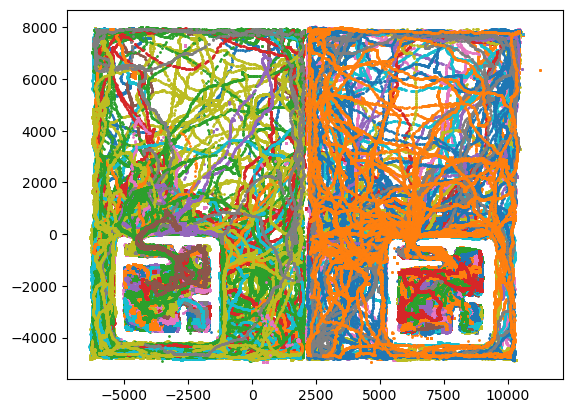

In [23]:
#Check if tracks make sense 

for group, data in active_arucos_col1.groupby('ARUCO_number'):
    plt.scatter(data['X'], data['Y'], s=1)

for group, data in active_arucos_col2.groupby('ARUCO_number'):
    plt.scatter(data['X'], data['Y'], s=1)

plt.show()


In [15]:
def check_individual_arucos( df):
    for aruco, data in df.groupby('ARUCO_number'):  
        plt.scatter(data['X'], data['Y'], s = 1)
        plt.xlim(-6000, 10200)
        plt.ylim(-5000, 8500)
        plt.title(str(aruco) )
        plt.show()

In [16]:
#check_individual_arucos(active_arucos_col1)

In [24]:
#Save the active_arucos (uncleaned) 
def convert_to_pickle(folder_path, pickle_name, df_to_convert): 
    #Create a new folder with the combined files in the desired directory 
    folder_name = folder_path.split('/')[-2]
    if not os.path.exists(folder_path):
        # If the folder does not exist, create it
        os.makedirs(folder_path)
        print(f"Folder '{folder_name}' created in '{folder_path}'.")
    else:
        print(f"Folder '{folder_name}' already exists in '{folder_path}'.")

    df_to_convert.to_pickle(folder_path +  pickle_name )
    
    return

convert_to_pickle(output_folder_path, exp_name + '_active_arucos_col1.pkl', active_arucos_col1)
convert_to_pickle(output_folder_path, exp_name + '_active_arucos_col2.pkl', active_arucos_col2)


Folder '20241109_3' already exists in '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241109_3/'.
Folder '20241109_3' already exists in '/run/user/1000/gvfs/smb-share:server=bucket.oist.jp,share=bucket/ReiterU/Anouk/basler_data/20241109_3/'.
